# EDA - Exploratory Data Analysis VCB

In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from load_data import load_vcb_data

# Thiết lập giao diện biểu đồ
sns.set_theme(style="whitegrid")

# 1. Đọc dữ liệu từ file CSV
df = load_vcb_data()

# 2. Tạo các cột biến trễ (Lag) và biến mục tiêu (Target) nếu chưa có
if "Close_Lag1" not in df.columns:
    df["Close_Lag1"] = df["Close"].shift(1)
if "Close_Lag2" not in df.columns:
    df["Close_Lag2"] = df["Close"].shift(2)
if "Next_Day_Close" not in df.columns:
    df["Next_Day_Close"] = df["Close"].shift(-1)

# 3. Lọc bỏ các dòng chứa giá trị khuyết (NaN) do shift tạo ra
cols_needed = [
    "Close",
    "Volume",
    "RSI",
    "Close_Lag1",
    "Close_Lag2",
    "Next_Day_Close",
]
df_clean = df.dropna(subset=cols_needed)

2026-07-24 01:13:12.101 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


D:\AdyFinal\database.py:142: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


Hình 1 — Biểu đồ phân phối (Distribution Plots)

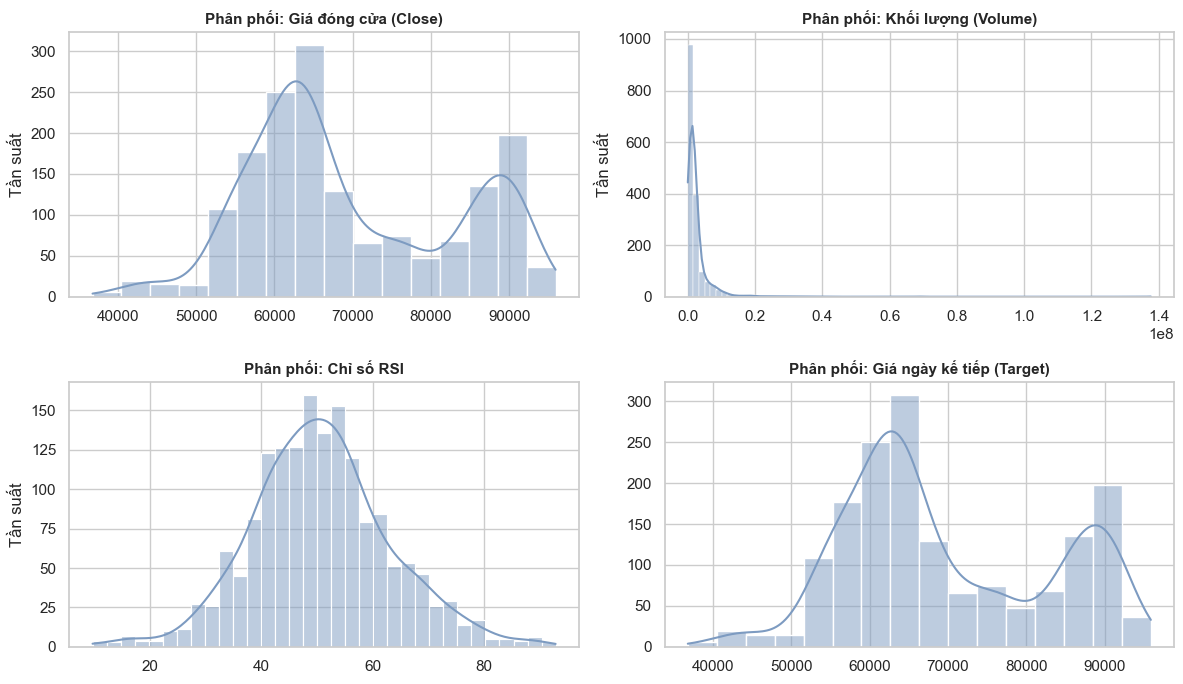

In [2]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

# Subplot 1: Giá đóng cửa (Close)
sns.histplot(
    data=df_clean, x="Close", kde=True, ax=axes[0, 0], color="#7D9BC1"
)
axes[0, 0].set_title(
    "Phân phối: Giá đóng cửa (Close)", fontsize=11, fontweight="bold"
)
axes[0, 0].set_ylabel("Tần suất")
axes[0, 0].set_xlabel("")

# Subplot 2: Khối lượng (Volume)
sns.histplot(
    data=df_clean, x="Volume", kde=True, ax=axes[0, 1], color="#7D9BC1"
)
axes[0, 1].set_title(
    "Phân phối: Khối lượng (Volume)", fontsize=11, fontweight="bold"
)
axes[0, 1].set_ylabel("Tần suất")
axes[0, 1].set_xlabel("")

# Subplot 3: Chỉ số RSI
sns.histplot(data=df_clean, x="RSI", kde=True, ax=axes[1, 0], color="#7D9BC1")
axes[1, 0].set_title("Phân phối: Chỉ số RSI", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("Tần suất")
axes[1, 0].set_xlabel("")

# Subplot 4: Giá ngày kế tiếp (Next_Day_Close)
sns.histplot(
    data=df_clean, x="Next_Day_Close", kde=True, ax=axes[1, 1], color="#7D9BC1"
)
axes[1, 1].set_title(
    "Phân phối: Giá ngày kế tiếp (Target)", fontsize=11, fontweight="bold"
)
axes[1, 1].set_ylabel("")
axes[1, 1].set_xlabel("")

plt.tight_layout()
plt.show()


Hình 2 — Biểu đồ tán xạ & Đường hồi quy (Scatter & Regression Plots)

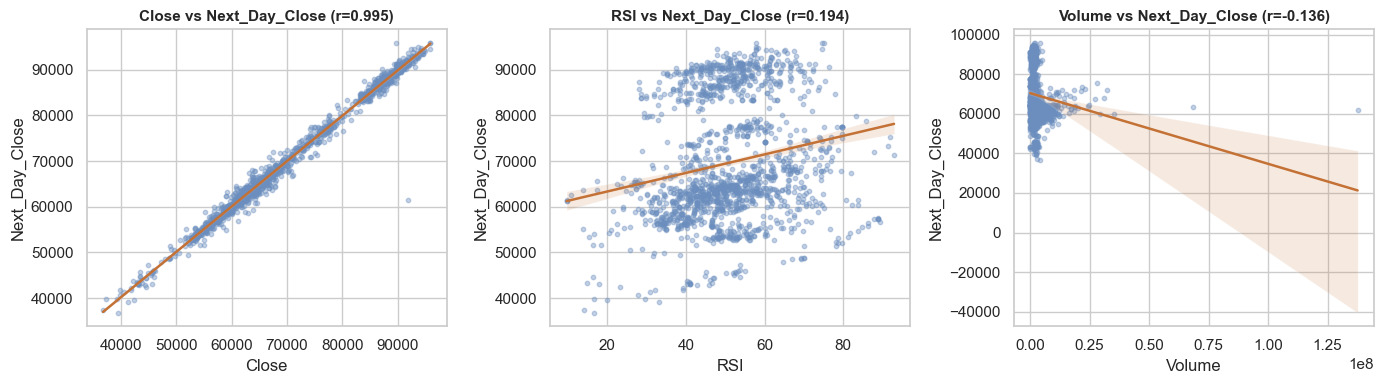

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

features = ["Close", "RSI", "Volume"]

for i, col in enumerate(features):
    # Tính hệ số tương quan Pearson r
    r_val = df_clean[col].corr(df_clean["Next_Day_Close"])

    # Vẽ scatter plot kèm đường hồi quy
    sns.regplot(
        data=df_clean,
        x=col,
        y="Next_Day_Close",
        ax=axes[i],
        scatter_kws={"s": 10, "alpha": 0.4, "color": "#6B8EBE"},
        line_kws={"color": "#C47135", "linewidth": 1.8},
    )

    axes[i].set_title(
        f"{col} vs Next_Day_Close (r={r_val:.3f})", fontsize=11, fontweight="bold"
    )
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Next_Day_Close")

plt.tight_layout()
plt.show()

Hình 3 — Ma trận tương quan Pearson (Heatmap)

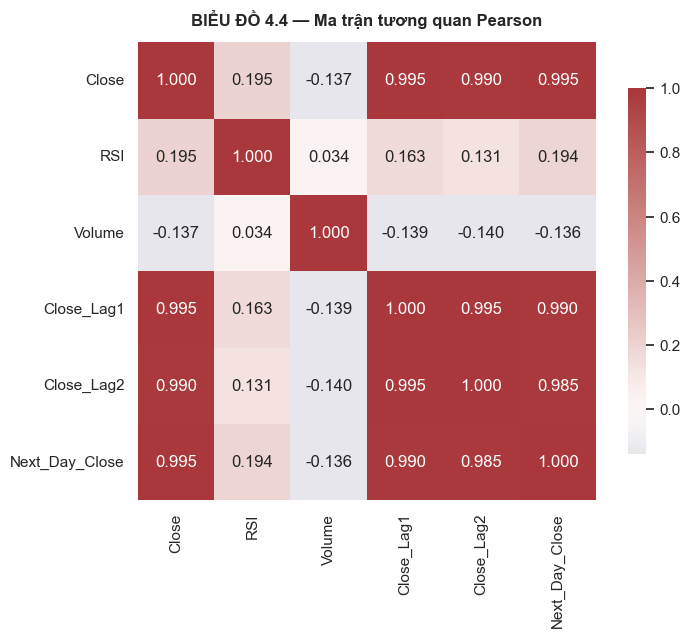

In [4]:
cols_corr = [
    "Close",
    "RSI",
    "Volume",
    "Close_Lag1",
    "Close_Lag2",
    "Next_Day_Close",
]
corr_matrix = df_clean[cols_corr].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="vlag",  # Bảng màu tương tự hình mẫu (từ xanh nhạt đến nâu đỏ)
    center=0,
    square=True,
    cbar_kws={"shrink": 0.8},
)

plt.title(
    "BIỂU ĐỒ 4.4 — Ma trận tương quan Pearson",
    fontsize=12,
    fontweight="bold",
    pad=12,
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [5]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

# ==========================================
# PHẦN 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)
# ==========================================
import pandas as pd
from load_data import load_vcb_data

# 1. Đọc dữ liệu từ file CSV, ép kiểu Date và đặt làm DatetimeIndex
df = load_vcb_data()
df_final = df.copy()

print("=" * 60)
print("   BÁO CÁO PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) - MÃ CỔ PHIẾU VCB")
print("=" * 60)

# 2.1. Hình dạng dữ liệu (Shape)
print("\n1. KÍCH THƯỚC TẬP DỮ LIỆU (SHAPE):")
print(f"- Tổng số dòng (phiên giao dịch): {df_final.shape[0]}")
print(f"- Tổng số cột (đặc trưng): {df_final.shape[1]}")

# 2.2. Kiểm tra tính toàn vẹn (Missing values)
print("\n2. KIỂM TRA DỮ LIỆU KHUYẾT THIẾU (MISSING VALUES):")
print(df_final.isnull().sum())

# 2.3. Cấu trúc và kiểu dữ liệu (Info - Ép hiển thị đầy đủ)
print("\n3. THÔNG TIN KIỂU DỮ LIỆU VÀ BỘ NHỚ (INFO):")
df_final.info(verbose=True, show_counts=True)

# 2.4. Thống kê mô tả (Descriptive Statistics)
print("\n4. THỐNG KÊ MÔ TẢ CƠ BẢN (DESCRIPTIVE STATISTICS):")
pd.set_option("display.float_format", lambda x: "%.2f" % x)
display(df_final.describe())

   BÁO CÁO PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA) - MÃ CỔ PHIẾU VCB

1. KÍCH THƯỚC TẬP DỮ LIỆU (SHAPE):
- Tổng số dòng (phiên giao dịch): 1653
- Tổng số cột (đặc trưng): 10

2. KIỂM TRA DỮ LIỆU KHUYẾT THIẾU (MISSING VALUES):
Close     0
High      0
Low       0
Open      0
Volume    0
RSI       0
MA10      0
MA20      0
MA50      0
MACD      0
dtype: int64

3. THÔNG TIN KIỂU DỮ LIỆU VÀ BỘ NHỚ (INFO):
<class 'pandas.DataFrame'>
DatetimeIndex: 1653 entries, 2020-03-11 to 2026-07-23
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1653 non-null   float64
 1   High    1653 non-null   float64
 2   Low     1653 non-null   float64
 3   Open    1653 non-null   float64
 4   Volume  1653 non-null   int64  
 5   RSI     1653 non-null   float64
 6   MA10    1653 non-null   float64
 7   MA20    1653 non-null   float64
 8   MA50    1653 non-null   float64
 9   MACD    1653 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 14

D:\AdyFinal\database.py:142: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,Close,High,Low,Open,Volume,RSI,MA10,MA20,MA50,MACD
count,1653.00,1653.00,1653.00,1653.00,1653.00,1653.00,1653.00,1653.00,1653.00,1653.00
mean,69534.53,70235.96,68886.18,69557.90,2503708.53,50.62,69524.68,69511.92,69480.95,0.60
std,13159.15,13186.98,13165.10,13172.21,4979404.19,12.60,13063.44,12977.65,12720.53,424.69
min,36785.29,37557.01,36399.43,36785.29,0.00,9.67,39807.85,41791.81,44216.94,-3595.88
25%,60275.98,60992.20,59702.94,60397.16,871341.00,42.50,60562.20,60783.73,60845.43,-196.54
50%,64861.30,65967.60,64293.80,64959.18,1404600.00,50.14,65047.75,64756.78,64768.76,1.64
75%,83369.27,84182.54,82804.11,83369.27,2449707.00,57.78,83836.14,83483.48,83806.43,204.40
max,95899.18,98951.40,95800.71,96982.22,137645361.00,92.90,94373.06,93821.69,92445.23,2118.79
